## Time Series Forecasting in R


Time series forecasting is a technique used to predict future values based on previously observed data points. In many real-world scenarios, data is collected sequentially over time—such as daily stock prices, monthly sales figures, yearly temperature records, or hourly website traffic. Time series forecasting leverages the historical patterns and trends in this time-ordered data to make predictions about future outcomes.

The core idea behind time series forecasting is that past observations contain valuable information about the underlying processes that drive the data. These processes might exhibit trends (long-term upward or downward movements), seasonality (recurrent patterns at regular intervals, such as yearly cycles), and noise (random fluctuations). By analyzing these patterns, time series models can project future data points with a certain level of accuracy.

Time series forecasting is widely used in a variety of fields, including finance (predicting stock prices), economics (forecasting GDP growth), energy (estimating demand), weather forecasting, and supply chain management. The goal is to make informed decisions based on data-driven insights, whether it's planning for future demand, optimizing resource allocation, or identifying potential risks.

Common methods of time series forecasting range from simple techniques like moving averages to more advanced statistical and machine learning models such as ARIMA (AutoRegressive Integrated Moving Average), exponential smoothing, and long short-term memory (LSTM) neural networks.

### Load Data for Time Series

The data for this time series example is Ice cream sales for three flavors of ice cream between 2017 and 2023. We are going to first display the historical information for all three ice cream flavors, and then fit a basic time-series model to the data to forecast the sales for 2024.

In [1]:
-- Read in the data from the source csv file and display within datalab to get the dataframe into R
SELECT *
FROM 'ice_cream_forecast.csv'

,YearMonth,Flavor,Units_Sold
0,2019-05-01 00:00:00+00:00,ButterPecan,71143.0
1,2018-05-01 00:00:00+00:00,CarmelPraline,20820.0
2,2022-03-01 00:00:00+00:00,RockyRoad,107031.0
3,2023-12-01 00:00:00+00:00,ButterPecan,73724.0
4,2019-08-01 00:00:00+00:00,CarmelPraline,51059.0
...,...,...,...
247,2020-09-01 00:00:00+00:00,ButterPecan,128792.0
248,2022-04-01 00:00:00+00:00,RockyRoad,166119.0
249,2021-02-01 00:00:00+00:00,ButterPecan,32237.0
250,2018-01-01 00:00:00+00:00,RockyRoad,56196.0


In [2]:
#Install the forecast R package
#The forecast package in R is a widely used tool for time series forecasting.

install.packages("forecast")

# Downloading packages -------------------------------------------------------
- Downloading forecast from CRAN ...            OK [1.5 Mb in 0.21s]
- Downloading fracdiff from CRAN ...            OK [96.2 Kb in 0.19s]
- Downloading lmtest from CRAN ...              OK [394.1 Kb in 0.19s]
- Downloading tseries from CRAN ...             OK [369.5 Kb in 0.21s]
- Downloading quadprog from CRAN ...            OK [30.1 Kb in 0.22s]
- Downloading quantmod from CRAN ...            OK [1 Mb in 0.19s]
- Downloading TTR from CRAN ...                 OK [512.1 Kb in 0.21s]
- Downloading urca from CRAN ...                OK [1 Mb in 0.2s]
- Downloading RcppArmadillo from CRAN ...       OK [1 Mb in 0.21s]
Successfully downloaded 9 packages in 4 seconds.

The following package(s) will be installed:
- forecast      [8.23.0]
- fracdiff      [1.5-3]
- lmtest        [0.9-40]
- quadprog      [1.5-8]
- quantmod      [0.4.26]
- RcppArmadillo [14.0.2-1]
- tseries       [0.10-58]
- TTR           [0.24.4]
- ur

## Ensuring there is no missing data

Missing values can significantly impact the accuracy and reliability of forecasting models. Time series data, which consists of observations ordered by time, typically needs to maintain the integrity of the sequence to preserve trends, seasonality, and other patterns. When data is missing—whether due to equipment failure, human error, or other reasons—it can cause issues in analysis and forecasting.



In [30]:
# Create a sequence of all months from the start to the end of the dataset
all_months <- seq(min(df$YearMonth), max(df$YearMonth), by = "month")

# Convert YearMonth column to Date type if it's not already
df$YearMonth <- as.Date(df$YearMonth)

# Find the missing months by comparing the sequence with the actual data
missing_months <- setdiff(all_months, df$YearMonth)

# Display the missing months, if any
print(missing_months)

numeric(0)


After confirming there are no missing months in our dataset, we want to plot the sales with a different line for each flavor. That is done in the code block below:

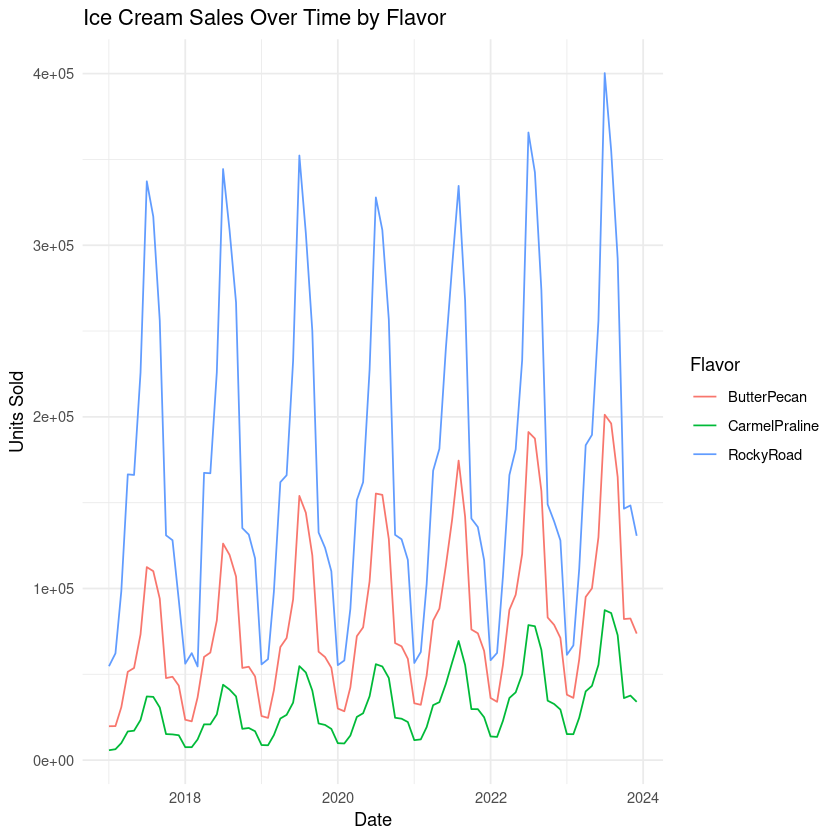

In [6]:
# Load necessary libraries
library(ggplot2)
library(dplyr)


# Plot df with a different line for each flavor
ggplot(df, aes(x = YearMonth, y = Units_Sold, color = Flavor)) +
  geom_line() +
  labs(title = "Ice Cream Sales Over Time by Flavor",
       x = "Date",
       y = "Units Sold") +
  theme_minimal()

We can see there is some seasonality in the data. Lets plot for the most recent year to get a clearer sense of which months have peak demand. Note that in a dashboard like on Domo, we can dynamically click and explore such a graphic, but not so in base R.

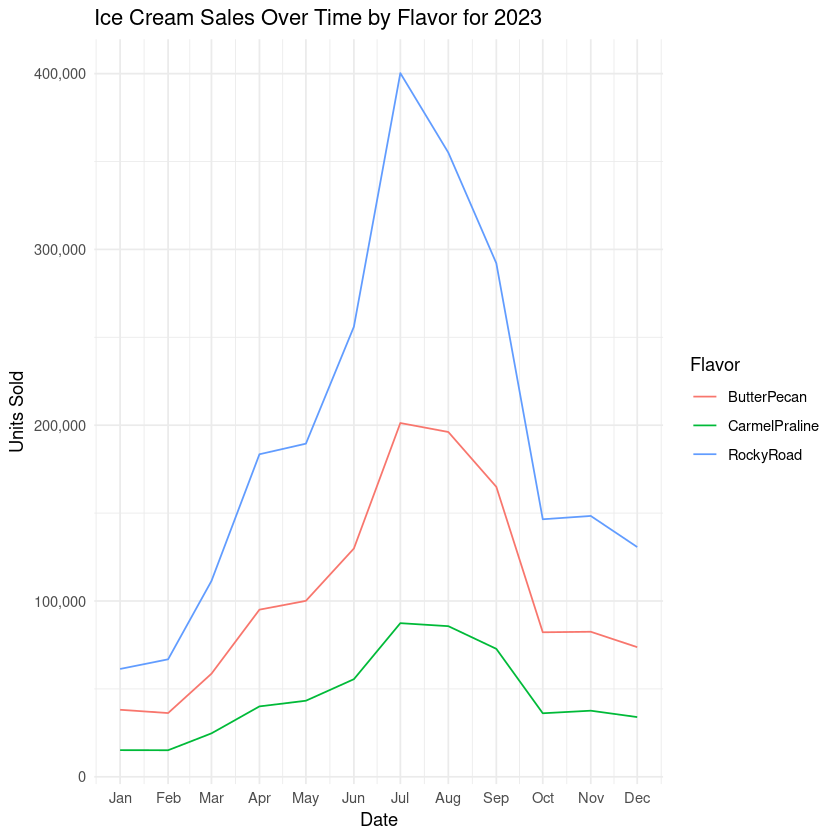

In [37]:
# Filter the dataframe for the most recent year
most_recent_year <- max(format(df$YearMonth, "%Y"))
df_recent_year <- df %>% filter(format(YearMonth, "%Y") == most_recent_year)

# Plot df with a different line for each flavor for the most recent year
ggplot(df_recent_year, aes(x = YearMonth, y = Units_Sold, color = Flavor)) +
  geom_line() +
  scale_x_date(date_breaks = "1 month", date_labels = "%b") +
  scale_y_continuous(labels = scales::comma) +
  labs(title = paste("Ice Cream Sales Over Time by Flavor for", most_recent_year),
       x = "Date",
       y = "Units Sold") + 
  theme_minimal()

## Forecasting of future sales (One Flavor at Time)
Next, we are going to forecast future sales of Butter Pecan ice cream first. The Time Series analysis assumes you are fitting a time series for a single piece of information at a time, so we cannot forecast for all three flavors at once.

In [38]:
butter_pecan_df <- subset(df, Flavor == "ButterPecan")
butter_pecan_df <- butter_pecan_df[order(butter_pecan_df$YearMonth), ]
head(butter_pecan_df)

,YearMonth,Flavor,Units_Sold
,<date>,<chr>,<dbl>
168,2017-01-01,ButterPecan,19752
33,2017-02-01,ButterPecan,19823
160,2017-03-01,ButterPecan,30816
191,2017-04-01,ButterPecan,51471
146,2017-05-01,ButterPecan,53697
81,2017-06-01,ButterPecan,73274


## The TS() Object

A ts object in R stands for time series object, and it is used to represent data points collected or recorded at successive, evenly spaced points in time. 

### Key Features of a ts Object:
1. Time-based structure: The data is organized by time. Each data point corresponds to a specific time period, such as months, years, or days.

2. Regular intervals: The data is collected at consistent intervals (e.g., monthly, quarterly, yearly).

3. Indexing with time: The ts object uses a time index to track when each data point was recorded. This time index is crucial for identifying seasonal patterns, trends, and other time-related behaviors in the data.

### Basic Structure:
A ts object has four main components:

1. Data values: The actual observed values (e.g., sales, temperature, stock prices).
2. Start: The starting time of the time series (e.g., the first month or year).
3. Frequency: The number of data points per unit of time (e.g., monthly data would have a frequency of 12 if the data spans over years).
4. (Optional) End: The ending time of the time series.

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2017,19752,19823,30816,51471,53697,73274,112456,110093,94058,47796,48571,43397
2018,23524,22598,36526,60130,62666,81325,126168,119561,106958,53718,54402,48763
2019,25684,24614,40685,65886,71143,93617,153950,144132,119238,63168,60025,53816
2020,30056,28459,42383,72206,77366,104174,155322,154560,128792,68189,66307,59029
2021,33119,32237,49276,81290,88280,113316,140182,174506,141802,76124,73886,63628
2022,36188,33973,55388,87585,96334,120087,191177,187371,156768,83097,78784,71196
2023,38126,36262,58650,95080,100094,129863,201236,196132,164932,82210,82506,73724


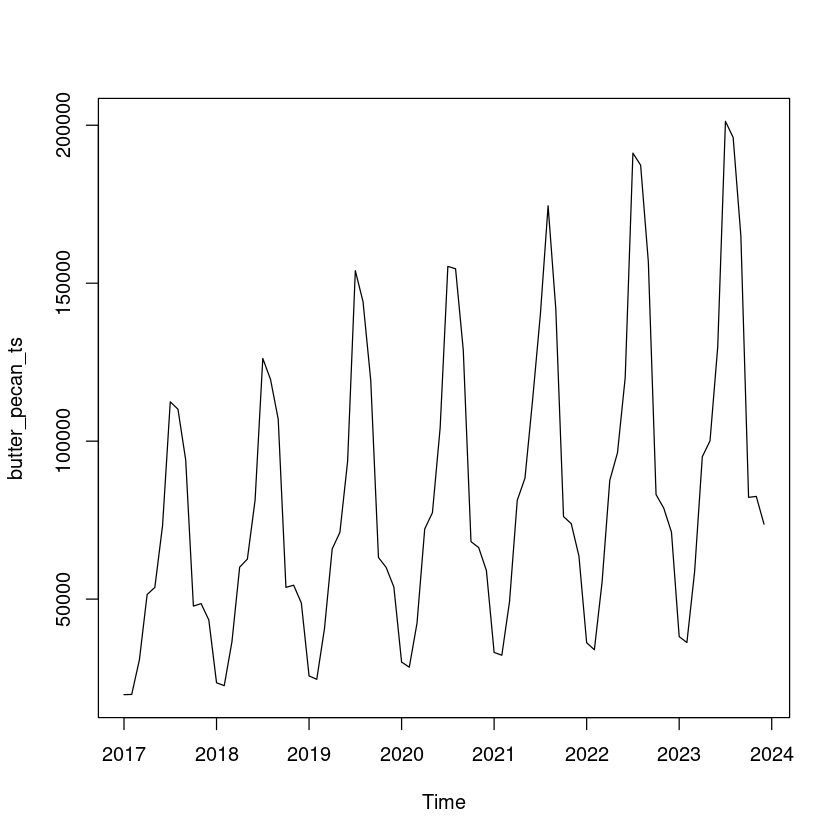

In [41]:
# Load necessary library
library(forecast)
library(lubridate)

# Create a time series object from butter_pecan_df sales
butter_pecan_ts <- ts(butter_pecan_df$Units_Sold, start = c(year(min(butter_pecan_df$YearMonth)), month(min(butter_pecan_df$YearMonth))), frequency = 12)

# Display the time series object
butter_pecan_ts
plot(butter_pecan_ts)

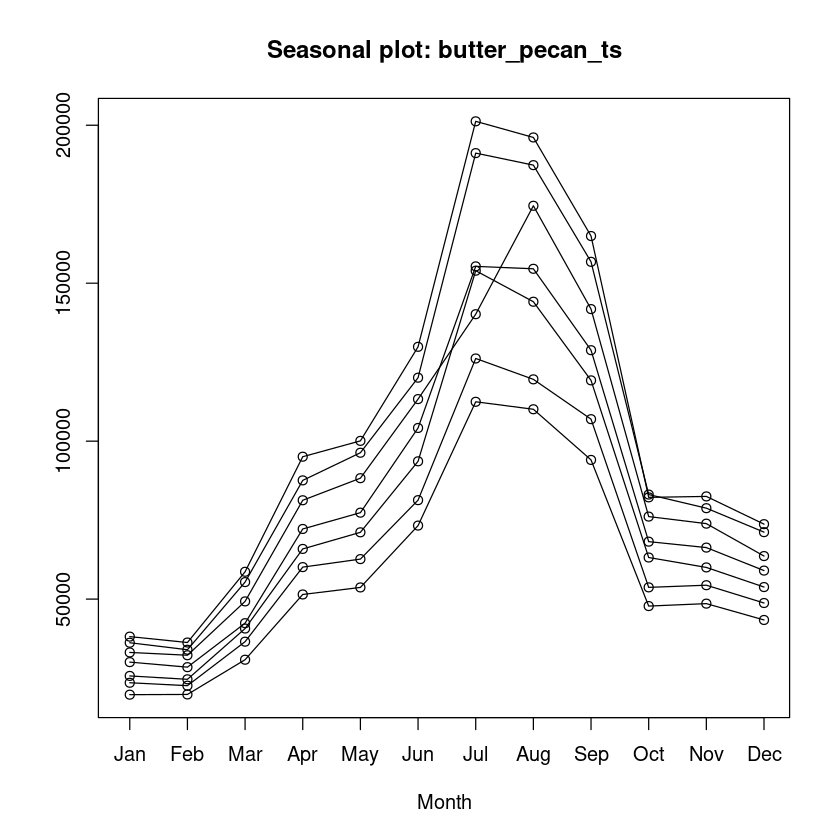

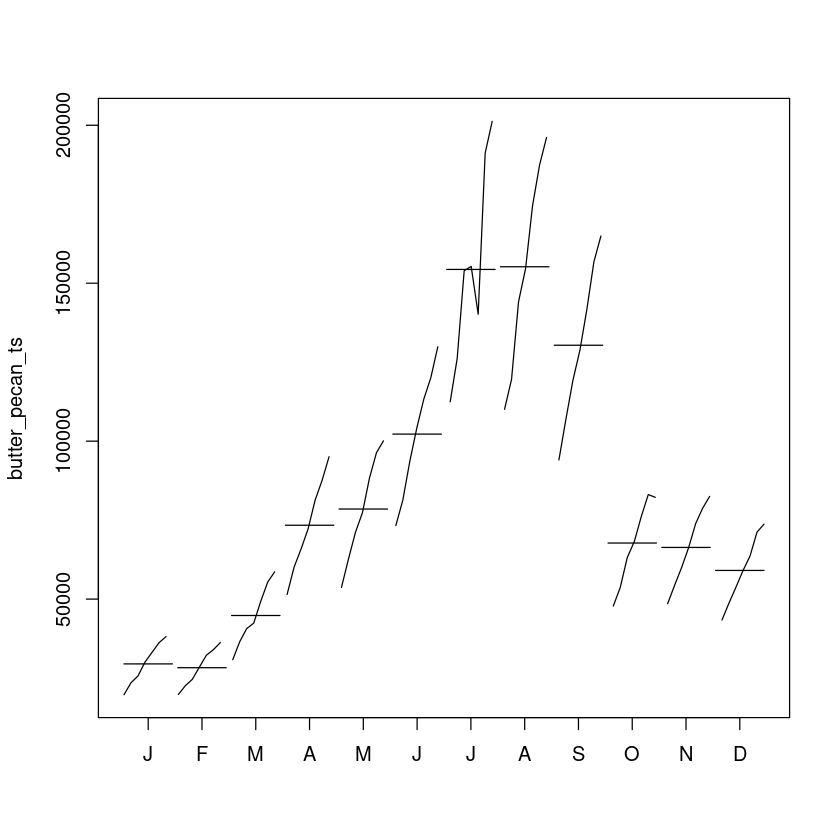

In [44]:
#performing some additional time series plots

seasonplot(butter_pecan_ts)
monthplot(butter_pecan_ts)

## STL (Seasonal-Trend decomposition using Loess method) 

STL decomposition is used to break down a time series into three main components:

1. Trend: The long-term movement or direction in the data (e.g., upward or downward).
2. Seasonal: The repeating fluctuations that happen at regular intervals (e.g., monthly, quarterly, yearly).
3. Residual (or Remainder): The noise or random variation that is left after removing the trend and seasonality. This part is often considered "unpredictable" or "random."

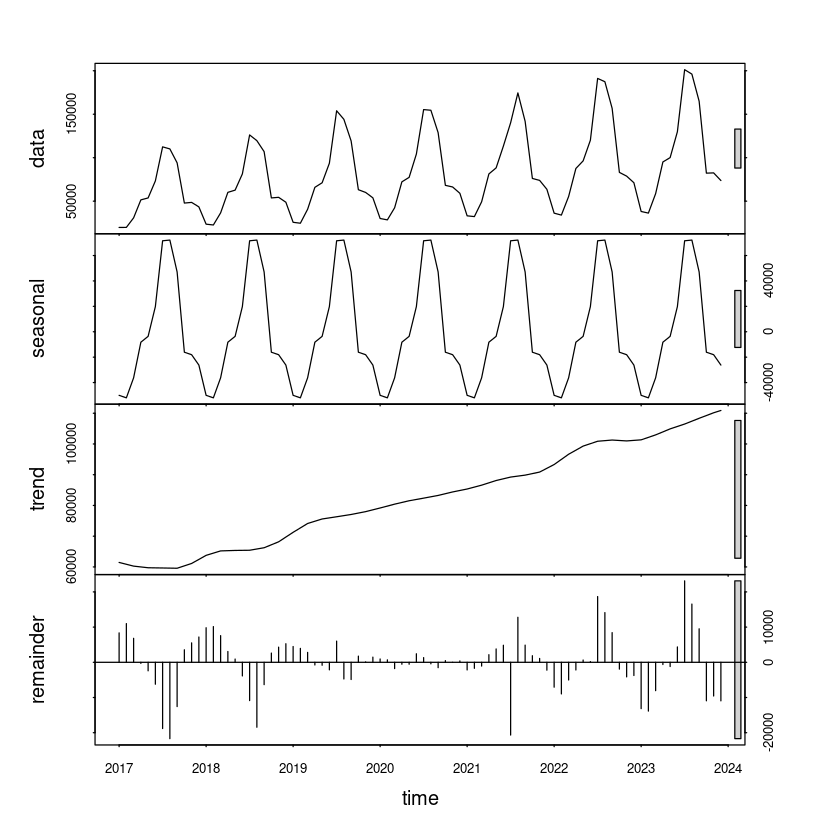

In [42]:
decomposed_sales_butter_pecan <- stl(butter_pecan_ts, s.window = "periodic")
plot(decomposed_sales_butter_pecan)

From this preliminary analysis, we can recognize both a linear trend (increasing sales over time) as well as a seasonal effect that is quite steady, although there is variation over time in the individual month sales records. There are other checks that you can perform on the data to gauge seasonality and correlation between data points, but that is out of scope for this quick demo. You can consult the 'More Information' section at the end of this notebook.

## ARIMA Model ()
An ARIMA (AutoRegressive Integrated Moving Average) model is a popular statistical model used for forecasting time series data. It combines three key components:

AR (AutoRegressive): This part models the relationship between an observation and a number of lagged observations (previous time steps). It uses the idea that past values of the series can help predict future values.

I (Integrated): This component involves differencing the time series to make it stationary, meaning that its statistical properties (like mean and variance) do not change over time. Differencing helps remove trends and seasonality in the data.

MA (Moving Average): This part models the relationship between an observation and a residual error from a moving average model (i.e. a number of previous months are averaged to predict the following month) applied to lagged observations. It helps capture random noise or shocks that affect the series.

Consider the notation for an ARIMA - ARIMA(p, d, q):
p is the order of the AR term (number of lagged observations).
d is the number of differencing steps required to make the series stationary.
q is the order of the MA term (number of lagged forecast errors).

Example:
To forecast a time series using an ARIMA(1,1,1) model, you would:

Apply one differencing step to make the data stationary (d=1).
Use one lagged value of the series for the AR part (p=1).
Use one lagged error for the MA part (q=1).

The `auto.arima()` function in R, provided by the forecast package, is an automated method to fit the best ARIMA (AutoRegressive Integrated Moving Average) model to a time series dataset. It automatically selects the best values for the model parameters (p, d, q), which define the ARIMA model's structure.

### Key Features of auto.arima():

1. Model Selection: It automatically identifies the optimal parameters for the ARIMA model based on criteria like AIC (Akaike Information Criterion), BIC (Bayesian Information Criterion), and other statistical tests.
2. Differencing: It automatically determines the appropriate number of differencing steps (d) required to make the data stationary.
3. Handling of Seasonality: It can also handle seasonality in the data if specified (seasonal = TRUE), selecting the appropriate seasonal ARIMA (SARIMA) model if necessary.
4. Efficiency: It simplifies the process of finding the best-fitting ARIMA model without having to manually experiment with different combinations of parameters.

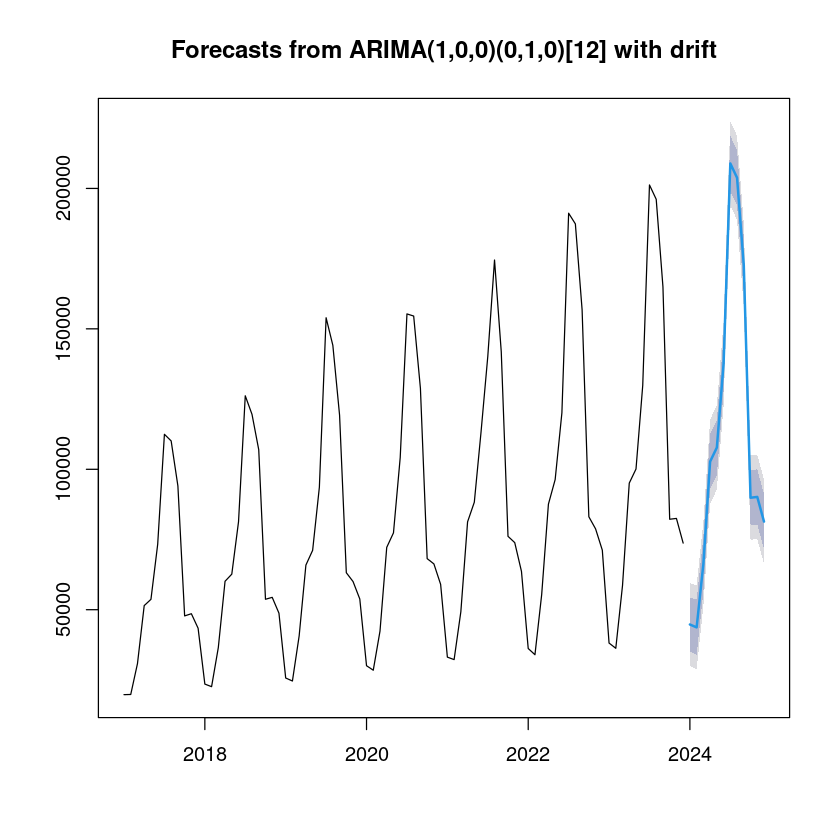

In [43]:
model_butter_pecan <- auto.arima(butter_pecan_ts) #fitting the auto.arima model to the time series object
forecast_butter_pecan <- forecast(model_butter_pecan, h = 12) #forecasting sales for the next 12 periods
plot(forecast_butter_pecan) #plotting the forecasted data

In [73]:

# Display the forecasted sales from forecast_butter_pecan in a table with YearMonth as Date
forecast_table <- data.frame(
  YearMonth = as.Date(time(forecast_butter_pecan$mean)),
  Forecasted_Units_Sold = as.numeric(forecast_butter_pecan$mean))

# Round forecasted units sold to integer
forecast_table$Forecasted_Units_Sold <- round(forecast_table$Forecasted_Units_Sold)

forecast_table

YearMonth,Forecasted_Units_Sold
<date>,<dbl>
2024-01-01,44739
2024-02-01,43706
2024-03-01,66264
2024-04-01,102728
2024-05-01,107749
2024-06-01,137520
2024-07-01,208893
2024-08-01,203789
2024-09-01,172589


In [75]:
# Load necessary library
library(reshape2)

# Create a pivot table of past sales by month in each column and years in rows
sales_pivot <- dcast(butter_pecan_df, format(YearMonth, "%Y") ~ format(YearMonth, "%b"), value.var = "Units_Sold")

# Order columns from Jan to Dec
month_order <- c("Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec")
sales_pivot <- sales_pivot[, c("format(YearMonth, \"%Y\")", month_order)]


# Add the forecasted units sold as the last row
forecast_row <- data.frame(t(forecast_table$Forecasted_Units_Sold))
colnames(forecast_row) <- format(forecast_table$YearMonth, "%b")
forecast_row <- cbind(Year = "2024_Forecast", forecast_row)

# Combine the sales pivot table with the forecast row
# Fix the column name issue by renaming the first column of sales_pivot to "Year"
colnames(sales_pivot)[1] <- "Year"
final_table <- rbind(sales_pivot, forecast_row)

# Display the final table
final_table

Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2017,19752,19823,30816,51471,53697,73274,112456,110093,94058,47796,48571,43397
2018,23524,22598,36526,60130,62666,81325,126168,119561,106958,53718,54402,48763
2019,25684,24614,40685,65886,71143,93617,153950,144132,119238,63168,60025,53816
2020,30056,28459,42383,72206,77366,104174,155322,154560,128792,68189,66307,59029
2021,33119,32237,49276,81290,88280,113316,140182,174506,141802,76124,73886,63628
2022,36188,33973,55388,87585,96334,120087,191177,187371,156768,83097,78784,71196
2023,38126,36262,58650,95080,100094,129863,201236,196132,164932,82210,82506,73724
2024_Forecast,44739,43706,66264,102728,107749,137520,208893,203789,172589,89867,90163,81381


In this notebook, we built a forecasting model to predict ice cream sales for the upcoming 12 months using historical sales data. The main goal was to generate reliable sales forecasts for one ice cream flavor (Butter Pecan). Below is an overview of the steps taken in the process:

### Data Preparation:

We began by reading in historical sales data, which was the number of units sold each month over a period of time.
We ensured that there were no missing months in the data, and then created the proper time series format (ts object in R).

### Exploratory Data Analysis (EDA):

We visualized the sales data to identify trends, seasonality, and any potential outliers. Seasonal patterns (e.g., higher sales in summer months) were observed, which were important for accurate forecasting.

### Model Selection:

We applied ARIMA (AutoRegressive Integrated Moving Average) modeling to the time series data using R's auto.arima() function. This method automatically selects the best-fitting ARIMA model. The model selection took into account seasonal patterns, trend components, and other relevant factors, ensuring the best fit for predicting future sales.

### Forecasting:

We used the ARIMA model to forecast ice cream sales for the next 12 months. The forecasted sales were accompanied by confidence intervals, providing an estimated range of sales based on the model's uncertainty.

### Results:

The forecasted ice cream sales for the upcoming year were displayed in a table, allowing stakeholders to understand expected demand. 

## Additional Resources

- Practical Time Series. Aileen Nielsen. https://learning.oreilly.com/library/view/practical-time-series/9781492041641/ 
- Manipulating Time Series Data in R. https://app.datacamp.com/learn/courses/manipulating-time-series-data-in-r
- A little book of R for Time Series. https://a-little-book-of-r-for-time-series.readthedocs.io/en/latest/
